# Play with remote sensing foundation model embeddings

**The task:** predict county-scale **maize yield** at 991 locations across Illinois (labels from [SPAM 2020](https://mapspam.info/)) using nothing but **frozen embeddings** from **14 remote-sensing foundation models**: GSE, Tessera, TerraMind, Clay, OlmoEarth, RemoteCLIP, SatMAE++, WildSAT, TerraFM, DOFA, THOR, SatVision, AgriFM and FoMo.

**The plan:**
1. See how one `rs-embed` call turns (lon, lat, time) into embeddings from any of these models
2. Download the precomputed embedding dataset from Hugging Face (~1.5 GB)
3. Train one tiny CNN per foundation model and compare them on the same test split

Everything below runs on CPU in a few minutes. A GPU makes it faster but is not required.


In [1]:
# If needed: %pip install -q huggingface_hub numpy pandas matplotlib torch scikit-learn
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import snapshot_download

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 1. Where these embeddings come from

`rs-embed` gives every foundation model the same interface: say **where**, **when**, and **which models** — it fetches the right Sentinel-2 (or MODIS) bands from Google Earth Engine, applies each model's own preprocessing, and runs the encoders. The full cache behind this tutorial came from one `export_batch` call:

```python
from rs_embed import ExportTarget, OutputSpec, PointBuffer, TemporalSpec, export_batch

manifests = export_batch(
    spatials=[PointBuffer(lon=lon, lat=lat, buffer_m=2048) for lon, lat in points],  # 991 SPAM points
    temporal=TemporalSpec.range("2019-06-01", "2019-08-31"),                         # growing season
    models=["gse", "tessera", "terramind", "clay", "olmoearth", "remoteclip", "satmaepp",
            "wildsat", "terrafm", "dofa", "thor", "satvision", "agrifm", "fomo"],
    output=OutputSpec.grid(),
    target=ExportTarget.per_item("demo_export", names=point_names),
    backend="gee",
)
```

That takes a few hours of GEE fetching and GPU inference and produces 146 GB of inputs + dense embeddings — so for the live session we pooled every embedding grid to **8 x 8** and published it on Hugging Face. That is all a yield model needs, and it is 100x smaller.


In [2]:
REPO_ID = "DingqiYe/rsembed-iguide-maize"

DATA = Path(snapshot_download(REPO_ID, repo_type="dataset"))
MODELS = sorted(p.stem for p in (DATA / "features").glob("*.npz"))
print(len(MODELS), "models:", ", ".join(MODELS))

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

14 models: agrifm, clay, dofa, fomo, gse, olmoearth, remoteclip, satmaepp, satvision, terrafm, terramind, tessera, thor, wildsat


## 2. The 991 sample points

`labels.csv` has one row per point: location, SPAM maize yield (t/ha), and a fixed train/test split so everyone in the room gets comparable numbers.


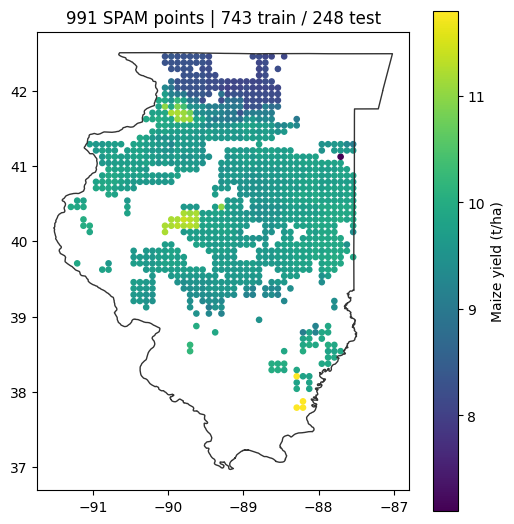

In [3]:
labels = pd.read_csv(DATA / "labels.csv")
y = labels["label"].to_numpy(np.float32)
train_mask = (labels["split"] == "train").to_numpy()
test_mask = (labels["split"] == "test").to_numpy()

boundary = json.loads((DATA / "illinois_boundary.json").read_text())

def draw_illinois(ax):
    polys = boundary["coordinates"] if boundary["type"] == "MultiPolygon" else [boundary["coordinates"]]
    for poly in polys:
        xy = np.asarray(poly[0])
        ax.plot(xy[:, 0], xy[:, 1], color="#333333", lw=1)

fig, ax = plt.subplots(figsize=(6, 6.5))
draw_illinois(ax)
sc = ax.scatter(labels["lon"], labels["lat"], c=y, s=14, cmap="viridis")
plt.colorbar(sc, label="Maize yield (t/ha)")
ax.set_title(f"{len(labels)} SPAM points | {train_mask.sum()} train / {test_mask.sum()} test")
ax.set_aspect("equal")
plt.show()

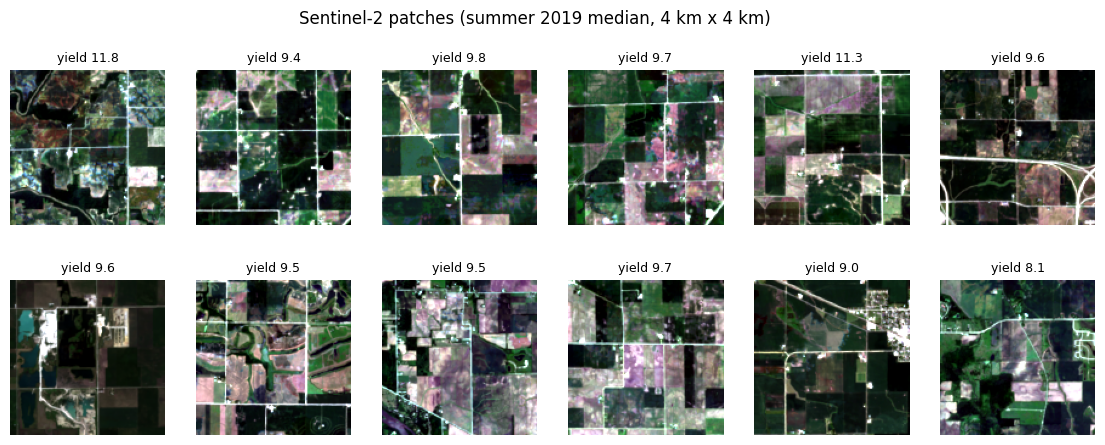

In [4]:
thumbs = np.load(DATA / "thumbnails.npz")["rgb"]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.flat, np.linspace(0, len(labels) - 1, 12, dtype=int)):
    ax.imshow(thumbs[i])
    ax.set_title(f"yield {y[i]:.1f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Sentinel-2 patches (summer 2019 median, 4 km x 4 km)")
plt.show()

## 3. One tiny CNN per foundation model

Each `features/<model>.npz` holds an array of shape `(991, C, 8, 8)` — that model's embedding grid for every point. The foundation models stay **frozen**; the only thing we train is this ~100K-parameter head, identical for every model. Whatever performance differences we see come from the embeddings themselves.


In [5]:
class ShallowCNN(nn.Module):
    """1x1 channel compression -> 3x3 conv -> global average pool -> linear head."""

    def __init__(self, c_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, 64, 1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def r2(y_true, y_pred):
    return 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()


def train_and_eval(name, epochs=30):
    X = np.load(DATA / "features" / f"{name}.npz")["X"].astype(np.float32)
    ok = np.isfinite(X).all(axis=(1, 2, 3))          # points where this model succeeded
    tr, te = train_mask & ok, test_mask & ok
    mu = X[tr].mean(axis=(0, 2, 3), keepdims=True)
    sd = X[tr].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    Xtr, ytr = torch.tensor((X[tr] - mu) / sd), torch.tensor(y[tr])
    Xte = torch.tensor((X[te] - mu) / sd)

    torch.manual_seed(42)
    net = ShallowCNN(Xtr.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(epochs):
        for i in torch.randperm(len(Xtr)).split(32):
            loss = F.mse_loss(net(Xtr[i].to(device)), ytr[i].to(device))
            opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        pred = net(Xte.to(device)).cpu().numpy()
    return r2(y[te], pred), pred, te


results = {}
for name in MODELS:
    results[name] = train_and_eval(name)
    print(f"{name:>12s}   test R2 = {results[name][0]:.3f}")

      agrifm   test R2 = 0.345
        clay   test R2 = 0.459
        dofa   test R2 = 0.044
        fomo   test R2 = 0.266
         gse   test R2 = 0.547
   olmoearth   test R2 = 0.521
  remoteclip   test R2 = -0.001
    satmaepp   test R2 = 0.156
   satvision   test R2 = 0.056
     terrafm   test R2 = 0.260
   terramind   test R2 = 0.452
     tessera   test R2 = 0.656
        thor   test R2 = 0.485
     wildsat   test R2 = 0.117


## 4. Which embeddings carry the most yield signal?


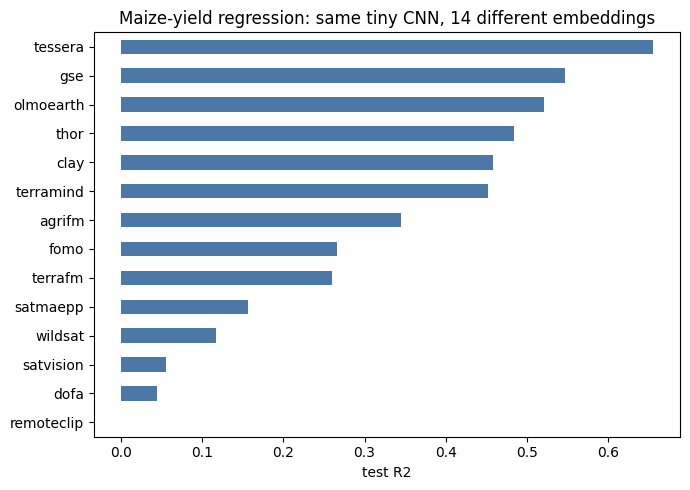

In [6]:
scores = pd.Series({m: res[0] for m, res in results.items()}).sort_values()

scores.plot.barh(color="#4c78a8", figsize=(7, 5))
plt.xlabel("test R2")
plt.title("Maize-yield regression: same tiny CNN, 14 different embeddings")
plt.tight_layout()
plt.show()

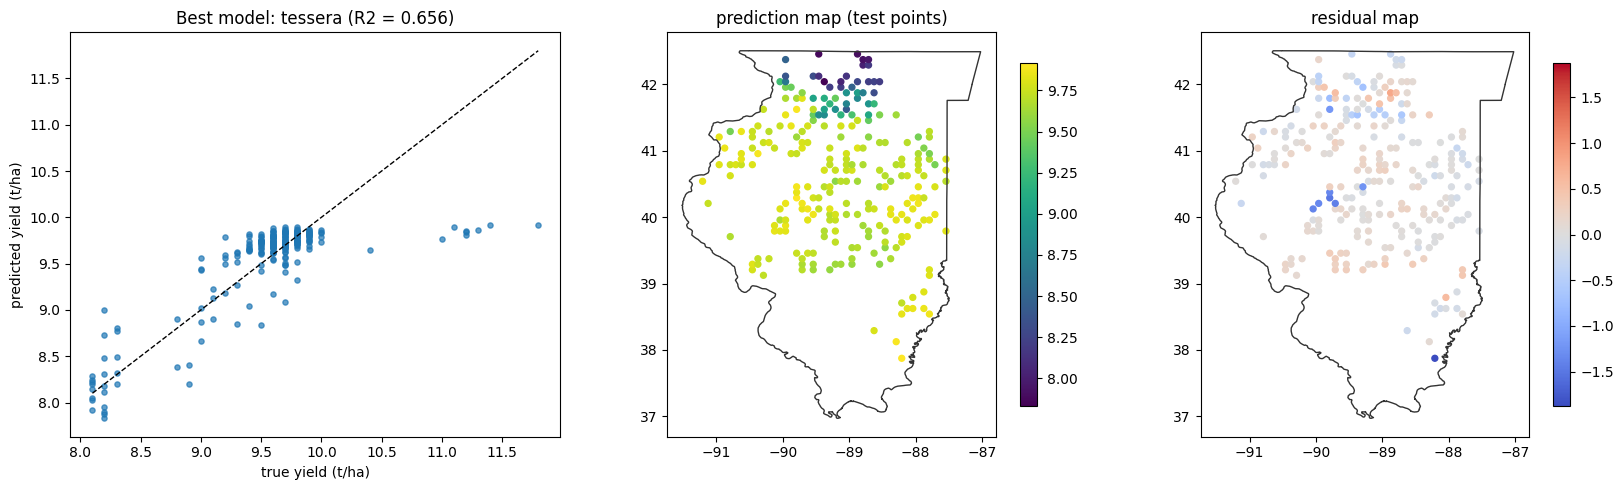

In [7]:
best = scores.idxmax()
_, pred, te = results[best]
truth = y[te]
resid = pred - truth

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))

axes[0].scatter(truth, pred, s=14, alpha=0.7)
axes[0].plot([truth.min(), truth.max()], [truth.min(), truth.max()], "k--", lw=1)
axes[0].set_xlabel("true yield (t/ha)")
axes[0].set_ylabel("predicted yield (t/ha)")
axes[0].set_title(f"Best model: {best} (R2 = {scores[best]:.3f})")

vmax = np.abs(resid).max()
for ax, vals, cmap, kw, title in [
    (axes[1], pred, "viridis", {}, "prediction map (test points)"),
    (axes[2], resid, "coolwarm", {"vmin": -vmax, "vmax": vmax}, "residual map"),
]:
    draw_illinois(ax)
    sc = ax.scatter(labels["lon"][te], labels["lat"][te], c=vals, s=18, cmap=cmap, **kw)
    plt.colorbar(sc, ax=ax, shrink=0.85)
    ax.set_title(title)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 5. What does each embedding *see*? Unsupervised segmentation

The CNN above compressed each embedding grid to a single number. But grid embeddings are
**dense feature maps** — every pixel is a feature vector. Running plain k-means on those
vectors (no labels, no training) shows which landscape structures each model separates.

The dataset ships one showcase location at full resolution (`showcase/p00144.npz`): a
reservoir surrounded by corn and soy fields. Note the very different native grid sizes —
from 4 x 4 (SatVision, 1 km MODIS) to 420 x 402 (Tessera, 10 m).


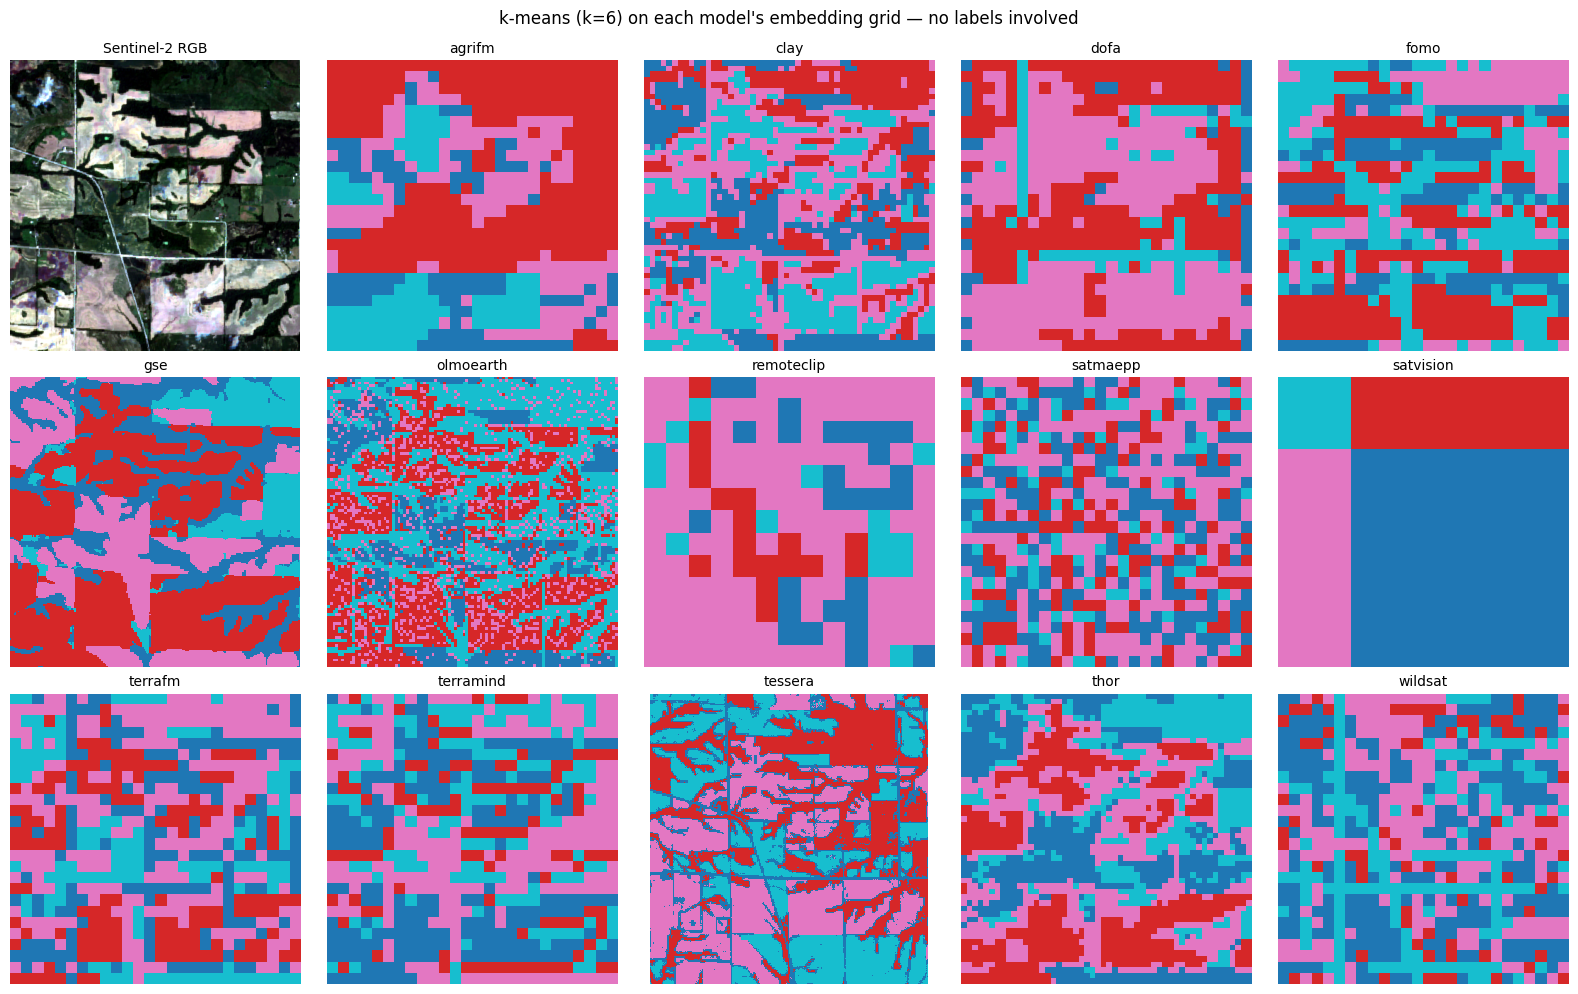

In [8]:
from sklearn.cluster import MiniBatchKMeans

pack = np.load(DATA / "showcase" / "p00144.npz")

def kmeans_map(E, k=4):
    C, H, W = E.shape
    pix = E.reshape(C, -1).T.astype(np.float32)
    pix = (pix - pix.mean(axis=0)) / (pix.std(axis=0) + 1e-6)
    return MiniBatchKMeans(k, random_state=42, n_init=4).fit_predict(pix).reshape(H, W)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes.flat[0].imshow(pack["rgb"])
axes.flat[0].set_title("Sentinel-2 RGB", fontsize=10)
for ax, name in zip(axes.flat[1:], MODELS):
    ax.imshow(kmeans_map(pack[f"emb__{name}"]), cmap="tab10", interpolation="nearest")
    ax.set_title(name, fontsize=10)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("k-means (k=6) on each model's embedding grid — no labels involved", y=0.99)
plt.tight_layout()
plt.show()

k-means forces hard boundaries. Projecting each pixel's feature vector onto its first
three **PCA components** and showing them as RGB gives the continuous view: similar colors =
similar embeddings. Fine texture here means the model keeps within-field detail; flat color
means it summarizes.


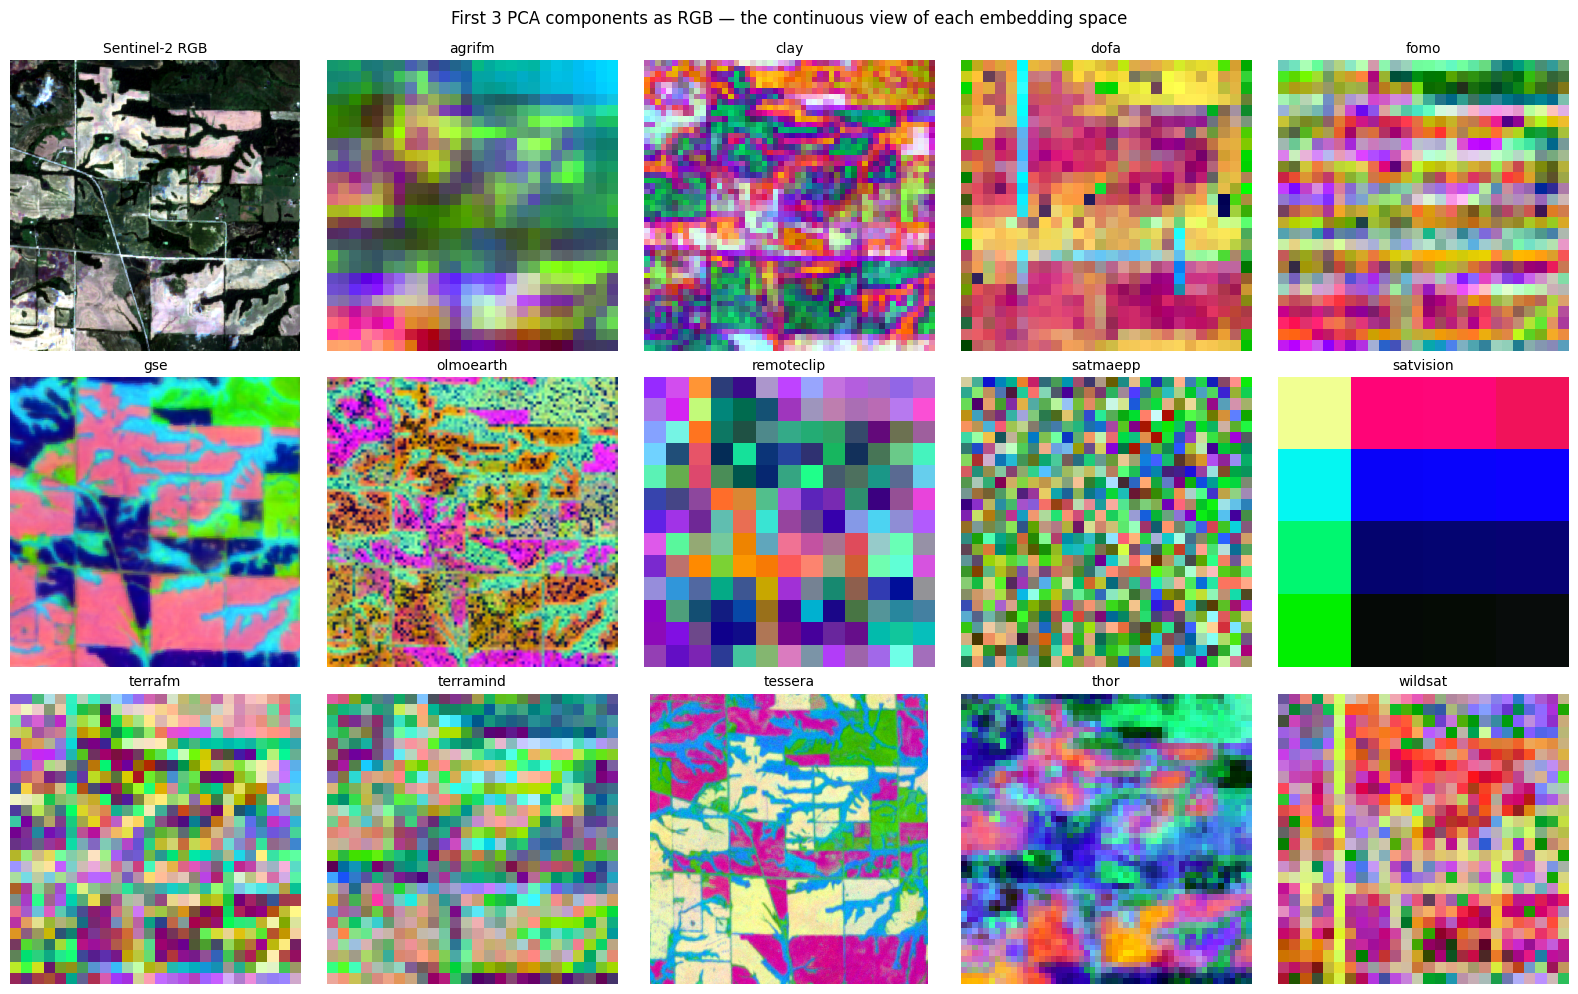

In [9]:
from sklearn.decomposition import PCA

def pca_map(E):
    C, H, W = E.shape
    pix = E.reshape(C, -1).T.astype(np.float32)
    pix = (pix - pix.mean(axis=0)) / (pix.std(axis=0) + 1e-6)
    comp = PCA(n_components=3).fit_transform(pix)
    lo, hi = np.percentile(comp, [2, 98], axis=0)
    return np.clip((comp - lo) / (hi - lo), 0, 1).reshape(H, W, 3)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes.flat[0].imshow(pack["rgb"])
axes.flat[0].set_title("Sentinel-2 RGB", fontsize=10)
for ax, name in zip(axes.flat[1:], MODELS):
    ax.imshow(pca_map(pack[f"emb__{name}"]))
    ax.set_title(name, fontsize=10)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("First 3 PCA components as RGB — the continuous view of each embedding space", y=0.99)
plt.tight_layout()
plt.show()

## 6. Retrieval: do similar embeddings imply similar yields?

Average-pool each 8 x 8 grid into one vector per point and the embeddings become a
searchable index: cosine similarity finds the places a model considers "most alike".
If an embedding really captures the growing conditions, a point's nearest neighbours
should also have similar yields.


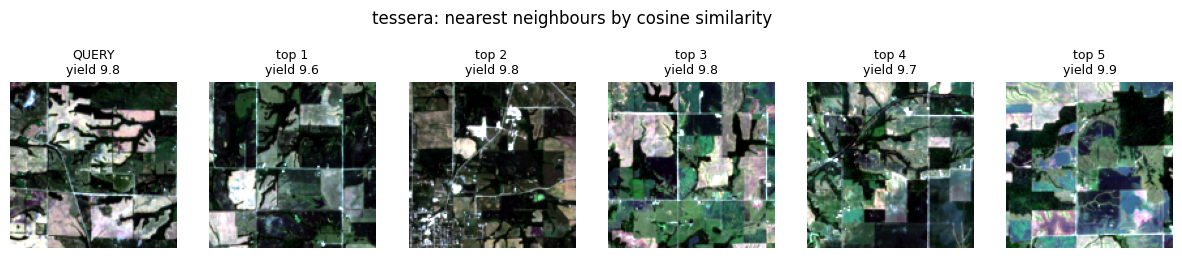

In [10]:
def gap_vectors(name):
    X = np.load(DATA / "features" / f"{name}.npz")["X"].astype(np.float32)
    ok = np.isfinite(X).all(axis=(1, 2, 3))
    V = X.mean(axis=(2, 3))                                  # (991, C) global average pool
    V /= np.linalg.norm(V, axis=1, keepdims=True) + 1e-9
    return V, ok

query = 144                                                  # same reservoir point as above
V, ok = gap_vectors(best)
sim = V @ V.T
np.fill_diagonal(sim, -np.inf)
sim[:, ~ok] = -np.inf

nn = np.argsort(-sim[query])[:5]
fig, axes = plt.subplots(1, 6, figsize=(15, 3.2))
for ax, i, tag in zip(axes, [query, *nn], ["QUERY", *(f"top {j + 1}" for j in range(5))]):
    ax.imshow(thumbs[i])
    ax.set_title(f"{tag}\nyield {y[i]:.1f}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"{best}: nearest neighbours by cosine similarity")
plt.show()

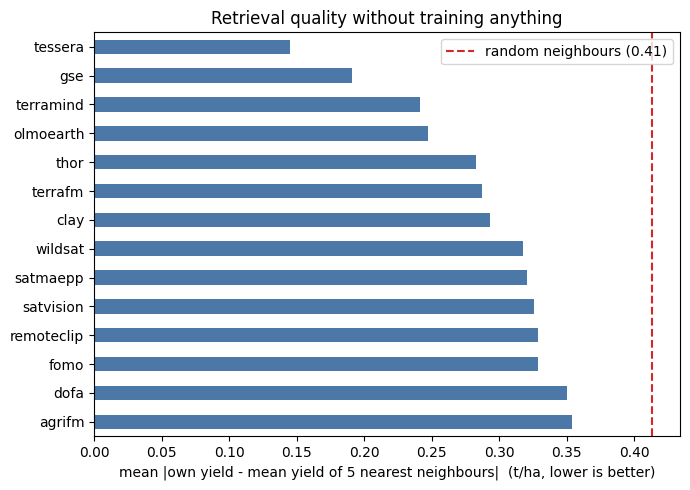

In [11]:
def neighbour_yield_gap(name, k=5):
    V, ok = gap_vectors(name)
    V, yy = V[ok], y[ok]
    sim = V @ V.T
    np.fill_diagonal(sim, -np.inf)
    nn = np.argsort(-sim, axis=1)[:, :k]
    return np.abs(yy[nn].mean(axis=1) - yy).mean()

gaps = pd.Series({name: neighbour_yield_gap(name) for name in MODELS}).sort_values(ascending=False)
rng = np.random.default_rng(42)
random_gap = np.abs(y[rng.integers(0, len(y), (len(y), 5))].mean(axis=1) - y).mean()

gaps.plot.barh(color="#4c78a8", figsize=(7, 5))
plt.axvline(random_gap, color="#d62728", ls="--", label=f"random neighbours ({random_gap:.2f})")
plt.xlabel("mean |own yield - mean yield of 5 nearest neighbours|  (t/ha, lower is better)")
plt.title("Retrieval quality without training anything")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Try it on your own problem

Everything above generalizes: swap the 991 maize points for **your** points and labels, and `rs-embed` handles the rest —

```python
from rs_embed import OutputSpec, PointBuffer, TemporalSpec, get_embeddings_batch

embs = get_embeddings_batch(
    "olmoearth",                       # any of the 14 models, same interface
    spatials=[PointBuffer(lon=lo, lat=la, buffer_m=2048) for lo, la in my_points],
    temporal=TemporalSpec.range("2023-06-01", "2023-08-31"),
    output=OutputSpec.grid(),
)
```

No per-model band bookkeeping, no per-model preprocessing code, no checkpoints to chase down.
